# Student Performance Factors Analysis using python

## 1. Introduction

This project analyzes the factors that affect student exam performance using a dataset from Kaggle.  
The goal is to explore how variables such as study hours, attendance, sleep hours, previous scores, parental involvement, motivation level, and access to resources influence exam scores.

This project uses:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

Dataset source:  
https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

### 1.1. Importing Libararies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

### 1.3. Setting plotstyle

In [2]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load dataset

In [3]:
df= pd.read_csv("/kaggle/input/datasets/lainguyn123/student-performance-factors/StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### 2.1. Checking Datasets

In [4]:
df.shape

(6607, 20)

In [5]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

### 2.2. Checking info about dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

### 2.3. Statistical Summary

In [7]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [8]:
df.columns=df.columns.str.lower()
df.columns

Index(['hours_studied', 'attendance', 'parental_involvement',
       'access_to_resources', 'extracurricular_activities', 'sleep_hours',
       'previous_scores', 'motivation_level', 'internet_access',
       'tutoring_sessions', 'family_income', 'teacher_quality', 'school_type',
       'peer_influence', 'physical_activity', 'learning_disabilities',
       'parental_education_level', 'distance_from_home', 'gender',
       'exam_score'],
      dtype='object')

## 3. Cleaning Dataset

### 3.1. Checking if there is null values 

In [27]:
df.isnull().sum()

hours_studied                 0
attendance                    0
parental_involvement          0
access_to_resources           0
extracurricular_activities    0
sleep_hours                   0
previous_scores               0
motivation_level              0
internet_access               0
tutoring_sessions             0
family_income                 0
teacher_quality               0
school_type                   0
peer_influence                0
physical_activity             0
learning_disabilities         0
parental_education_level      0
distance_from_home            0
gender                        0
exam_score                    0
dtype: int64

### 3.2. Filing the null values

In [26]:
df.fillna("N/A",inplace=True)

### 3.3. Checking duplicated values

In [10]:
df.duplicated().sum()

np.int64(0)

### 3.4. Identifying numerical and categorical columns

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numeric Columns:
Index(['hours_studied', 'attendance', 'sleep_hours', 'previous_scores',
       'tutoring_sessions', 'physical_activity', 'exam_score'],
      dtype='object')

Categorical Columns:
Index(['parental_involvement', 'access_to_resources',
       'extracurricular_activities', 'motivation_level', 'internet_access',
       'family_income', 'teacher_quality', 'school_type', 'peer_influence',
       'learning_disabilities', 'parental_education_level',
       'distance_from_home', 'gender'],
      dtype='object')


### 3.5. Identify Target variable

In [12]:
df["exam_score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: exam_score, dtype: float64

## 4. Exploratary Data Analysis


### 4.1. Distribution of exam scores

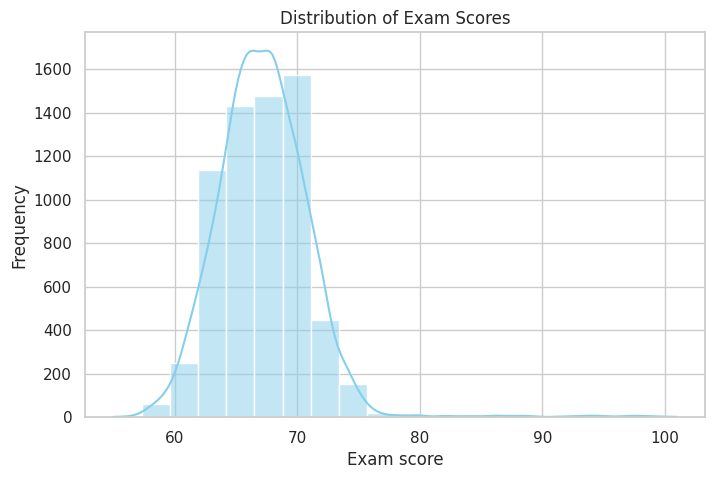

In [13]:
sns.histplot(df["exam_score"],bins=20, kde=True ,color="skyblue")
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam score")
plt.ylabel("Frequency")
plt.show()


### 4.2. Boxplot of Exam score
We used a boxplot to check the spread of exam scores and detect any possible outliers.

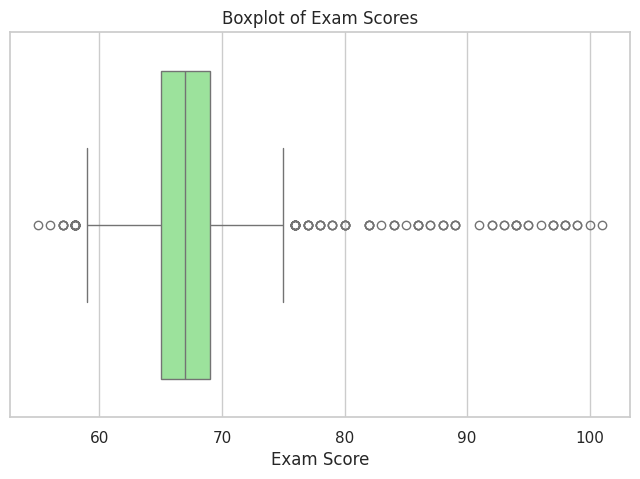

In [14]:
sns.boxplot(x=df["exam_score"], color="lightgreen")
plt.title("Boxplot of Exam Scores")
plt.xlabel("Exam Score")
plt.show()

### 4.3. Correlation Heatmap
We used a correlation heatmap to examine the relationships between numerical variables and identify which ones are most related to exam scores.

<Axes: >

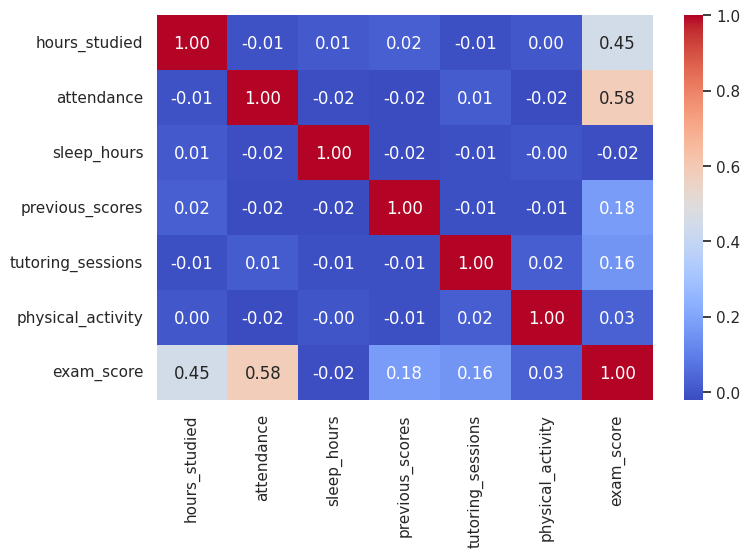

In [15]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")

### 4.4. Hours studied vs Exam score

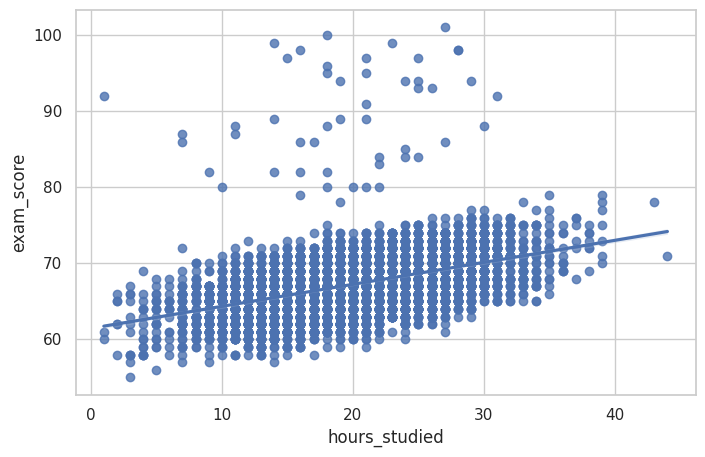

In [16]:
sns.regplot(data=df, x="hours_studied", y="exam_score")
plt.show()

### 4.5. Attendance vs Exam score

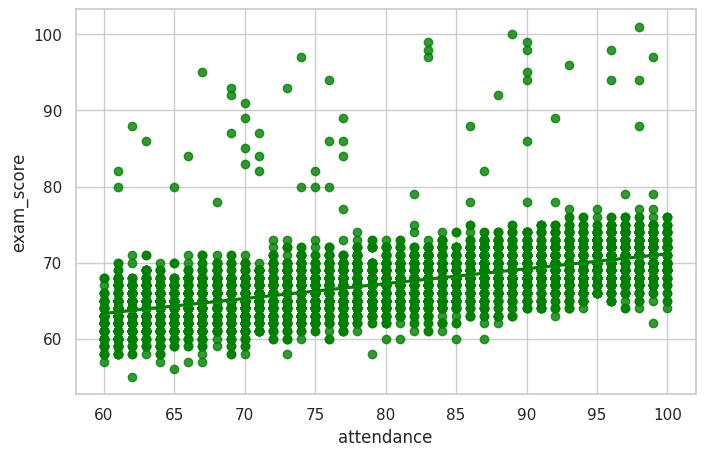

In [17]:
sns.regplot(data=df, x="attendance", y="exam_score",color="green")
plt.show()

### 4.6. Sleep hours vs Exam score

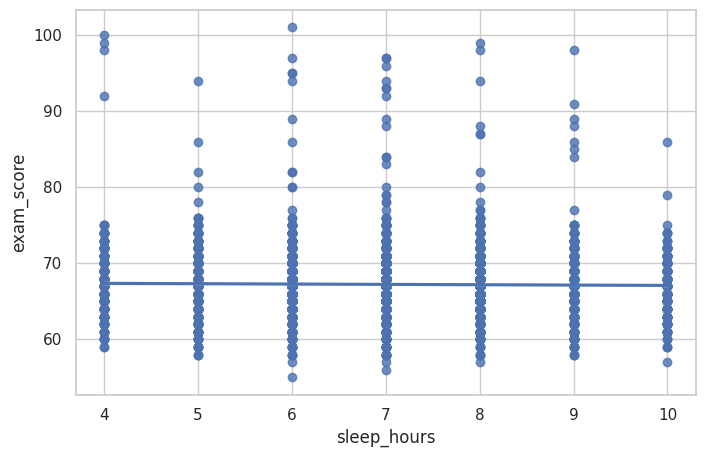

In [18]:
sns.regplot(data=df, x="sleep_hours", y="exam_score")
plt.show()

### 4.7. Previous Score vs Exam Score

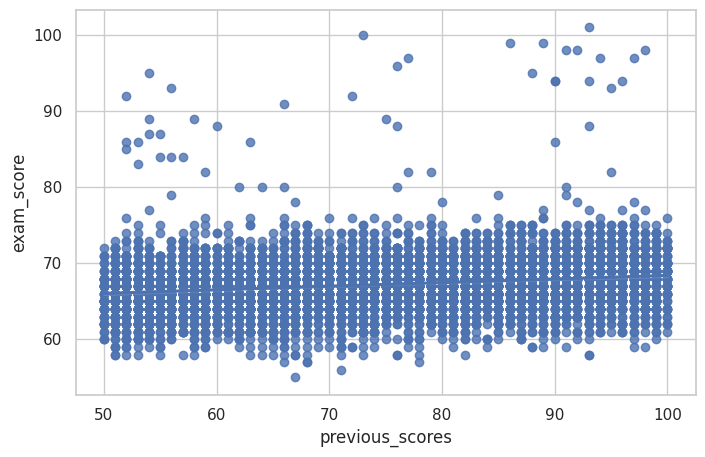

In [19]:
sns.regplot(data=df, x="previous_scores", y="exam_score")
plt.show()

### 4.8. Tutoring Sessions vs Exam score

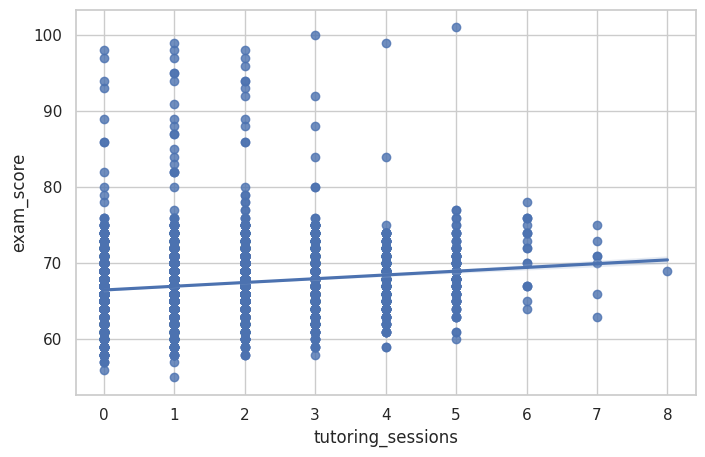

In [20]:
sns.regplot(data=df, x="tutoring_sessions", y="exam_score")
plt.show()

## 5. Categorical Data Analysis

### 5.1. Motivation level vs Exam score

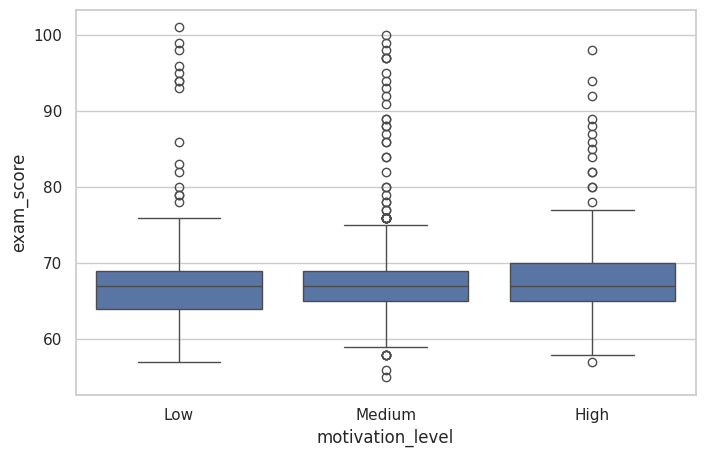

In [23]:
sns.boxplot(data=df,x="motivation_level", y="exam_score")
plt.show()

### 5.2. Parental involvement vs Exam score

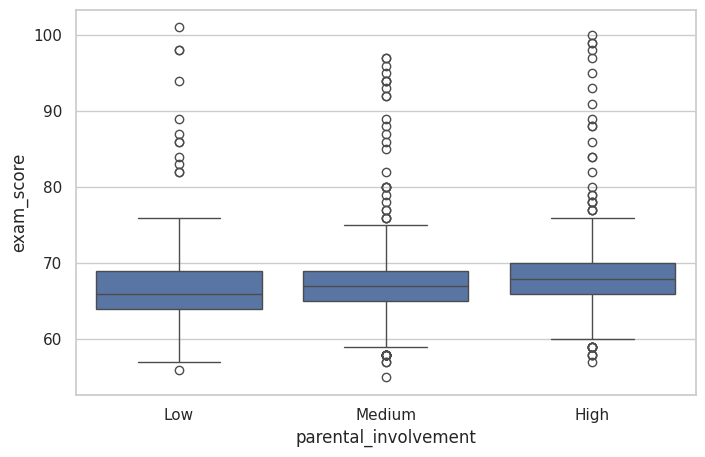

In [25]:
sns.boxplot(data=df, x="parental_involvement", y="exam_score")
plt.show()

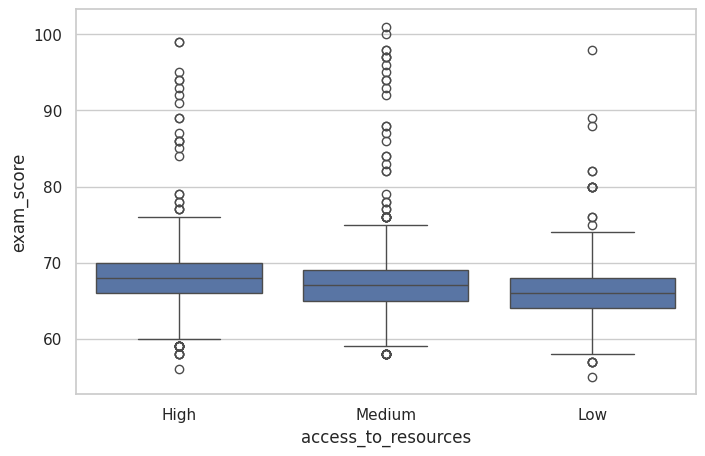

In [46]:
sns.boxplot(data=df, x="access_to_resources", y="exam_score")
plt.show()

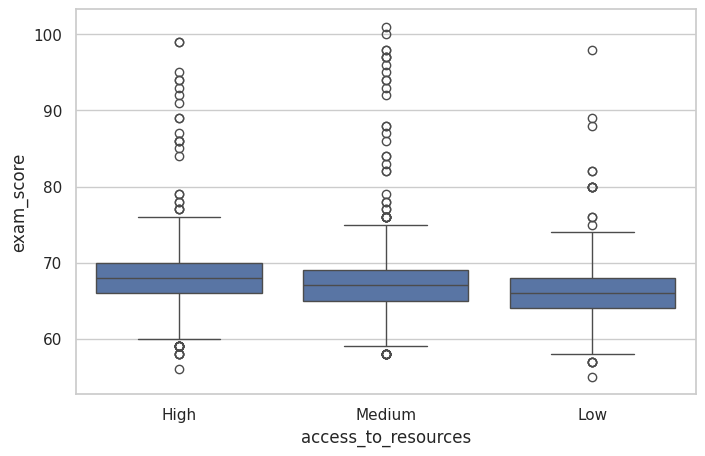

In [47]:
sns.boxplot(data=df, x="access_to_resources", y="exam_score")
plt.show()

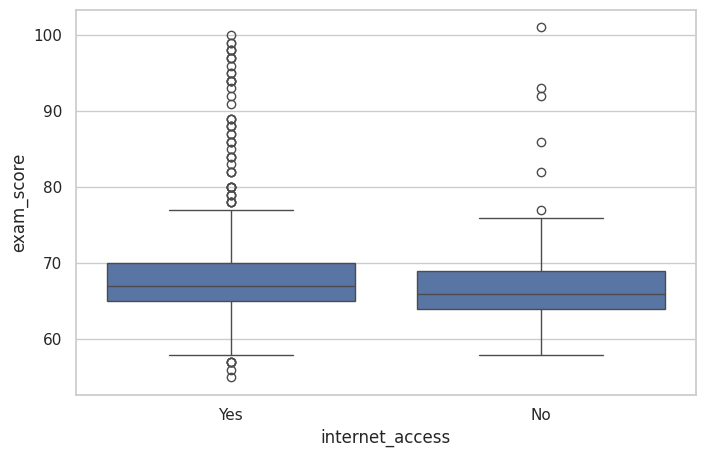

In [48]:
sns.boxplot(data=df, x="internet_access", y="exam_score")
plt.show()

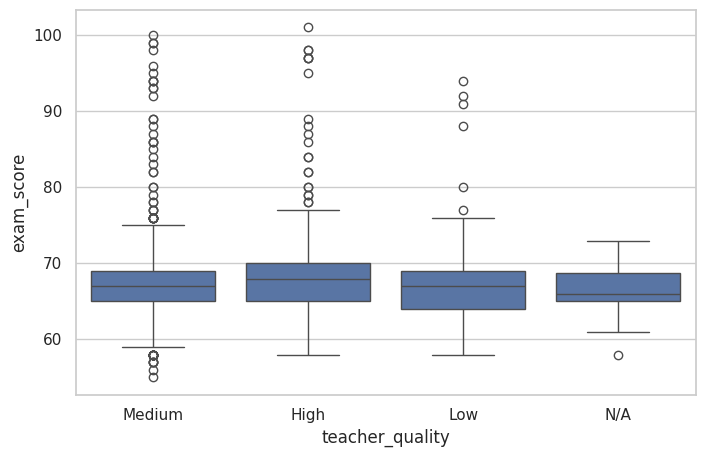

In [49]:
sns.boxplot(data=df, x="teacher_quality", y="exam_score")
plt.show()

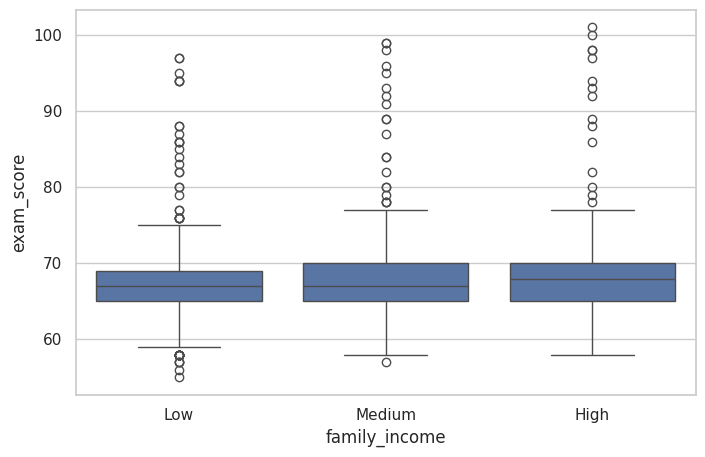

In [50]:
sns.boxplot(data=df, x="family_income", y="exam_score")
plt.show()


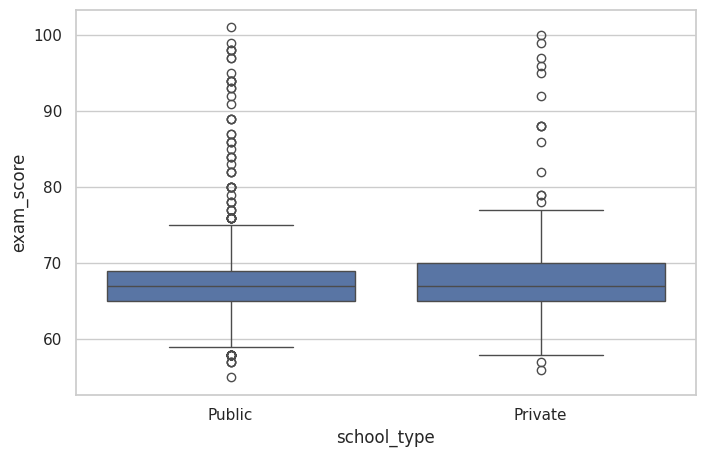

In [51]:
sns.boxplot(data=df, x="school_type", y="exam_score")
plt.show()

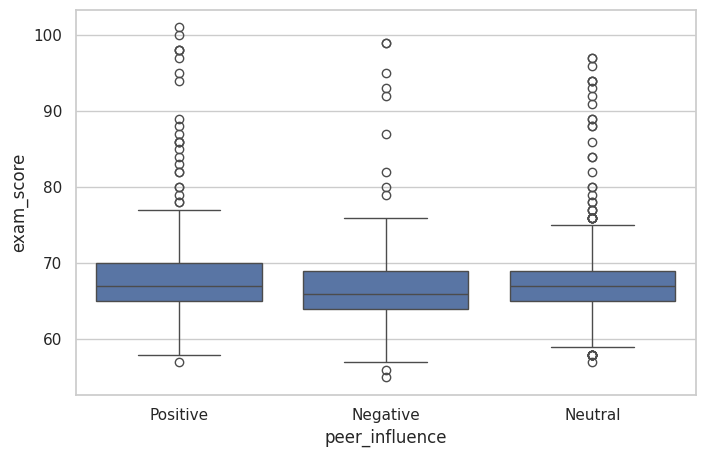

In [52]:
sns.boxplot(data=df, x="peer_influence", y="exam_score")
plt.show()

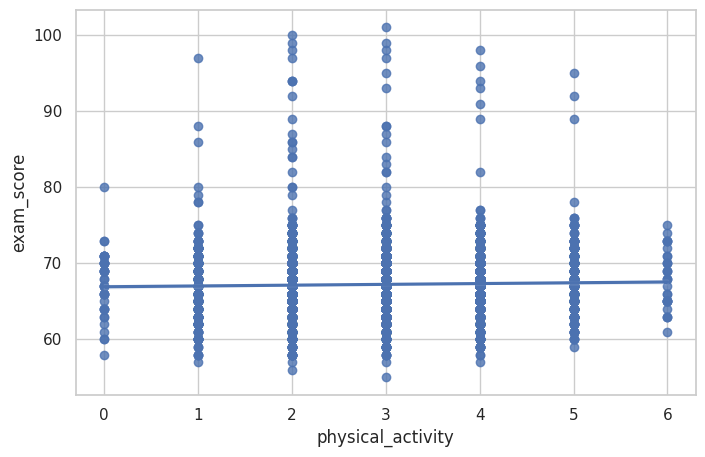

In [53]:
sns.regplot(data=df, x="physical_activity", y="exam_score")
plt.show()

## 6. Groupby Mean Analysis

In [65]:
df.groupby("parental_involvement")["exam_score"].mean().sort_values(ascending=False)

parental_involvement
High      68.092767
Medium    67.098156
Low       66.358265
Name: exam_score, dtype: float64

In [60]:
df.groupby("motivation_level")["exam_score"].mean()

motivation_level
High      67.704321
Low       66.752194
Medium    67.330648
Name: exam_score, dtype: float64

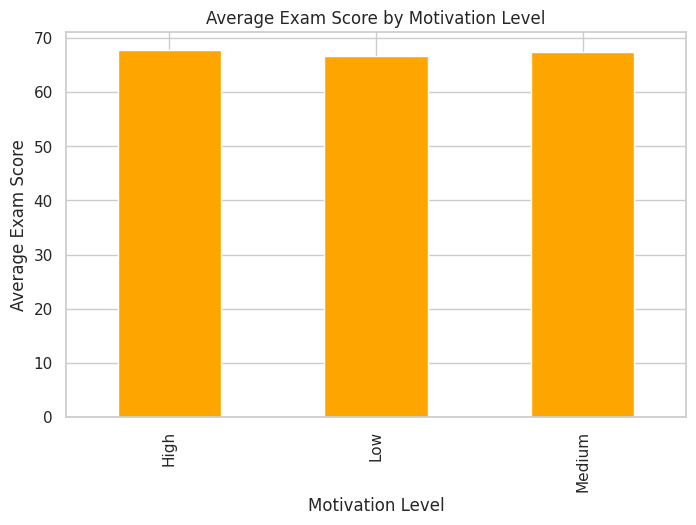

In [66]:
df.groupby("motivation_level")["exam_score"].mean().plot(kind="bar", color="orange")
plt.title("Average Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")
plt.show()

## 7. Key Insight
- Exam scores appear to be positively related to hours studied and attendance.
- Previous scores show a strong relationship with current exam scores.
- Students with higher motivation levels tend to achieve better marks.
- Students with good amount of sleep tend to have better marks.
- Better parental involvement and access to resources may support improved performance.
- Internet access and teacher quality also appear to influence student outcomes.
- Motivation level, parental involvement, and access to resources show noticeable differences in exam scores.

## 7. Conclusion

This project explored the factors affecting student academic performance using exploratory data analysis and visualization.

The analysis suggests that academic factors such as hours studied, attendance, and previous scores have a noticeable relationship with exam results. In addition, environmental and personal factors such as parental involvement, motivation, access to resources, and teacher quality may also influence student performance.

This project helped strengthen my skills in:
- data cleaning
- exploratory data analysis
- data visualization
- interpreting patterns in data using Python